## Exploratory Data Analysis (EDA)

# Exploratory Data Analysis | EDA

Exploratory Data Analysis (EDA) aims to uncover underlying patterns, spot anomalies, test hypotheses, and check assumptions through a detailed examination of the dataset. By performing EDA, we mitigate the risk of misleading or inaccurate results, leading to more effective and informed decision-making in various fields, from business to scientific research.<br>


**1. Understanding the Dataset**<br>
Initial Data Inspection: Familiarize yourself with the dataset. What is the nature of the data? time series, categorical, continuous etc. Make sure you understand the columns, and understand their types e.g. nominal, ordinal, interval, ratio.
<br>

**2. Data Cleaning and Preprocessing **<br>
Identify missing values and decide on strategies like imputation or removal.
Data Type Conversion - Ensure that each variable is of the correct type e.g. int, float, object or datetime. Check for and remove any duplicate records.
<br>

**3. Univariate Analysis**<br>
Categorical Data: Use bar charts to understand the distribution.
Continuous Data: Apply histograms, box plots, or density plots to understand the distribution and identify any outliers.
<br>

**4. Bivariate/Multivariate Analysis**<br>
Visualize correlation matrices as a heatmap  to identify relationships between numerical variables. Use scatter plots or pair plots for visualizing relationships between pairs of continuous variables.

Use `groupby()` and double `groupby()` + `unstack()` for categorical variables. Visualize as `sns.barplots()` and  `sns.barplots()` with a `hue=`. Double `groupby()` + `unstack()` can be visualized as heatmaps as well.

Split up continuous variables across a categorical column to visualize and compare the distributions.
<br>

In [18]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## 1. Understand the dataset and its columns

In [3]:
df = pd.read_csv("titanic.csv")

In [9]:
df.head(20)
#waht do the values look liek and col names and some values, try to figure what unknown columns are

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN
5,0,3,male,NaN,0,0,8.4583,Q,NaN
6,0,1,male,54.0,0,0,51.8625,S,E
7,0,3,male,2.0,3,1,21.0750,S,NaN
8,1,3,female,27.0,0,2,11.1333,S,NaN
9,1,2,female,14.0,1,0,30.0708,C,NaN


In [ ]:
df.info()
#data types, missing values 

In [ ]:
df.describe()
#distribution of data 

In [4]:
df.describe(include="str")

,sex,embarked,deck
count,891,889,203
unique,2,3,7
top,male,S,C
freq,577,644,59


In [ ]:
##        numerical          categorical
#          ||    ||           ||     ||
#          \/.   \/.          \/.    \/
# categorical.   discrete. nominal   ordinal 

In [ ]:
# survived = nominal
# plass = ordinal
# sex = nominal
# age = continuos
# sbisp = disc
# parch = disc
# fare = cont
# embarked = nom
# deck = nom 
#
#
#

In [23]:
continuos = ["age","fare"]
discrete = ["sibsp","parch"]

nominal = ["survived","sex","embarked","deck"]
ordinal = ["pclass"]

numerical = continuos + discrete
categorical = nominal + ordinal

<Axes: >

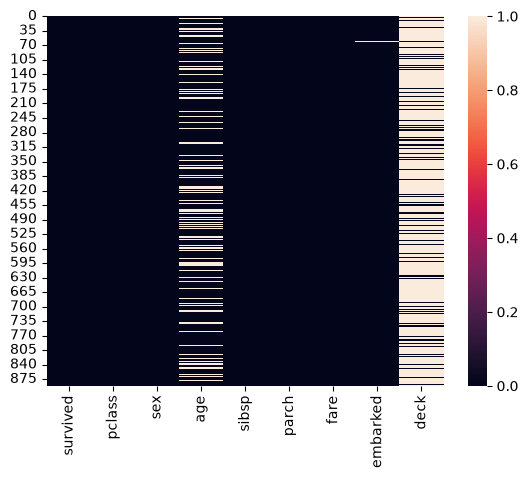

In [10]:
sns.heatmap(df.isna())

#3. Univariate analysis

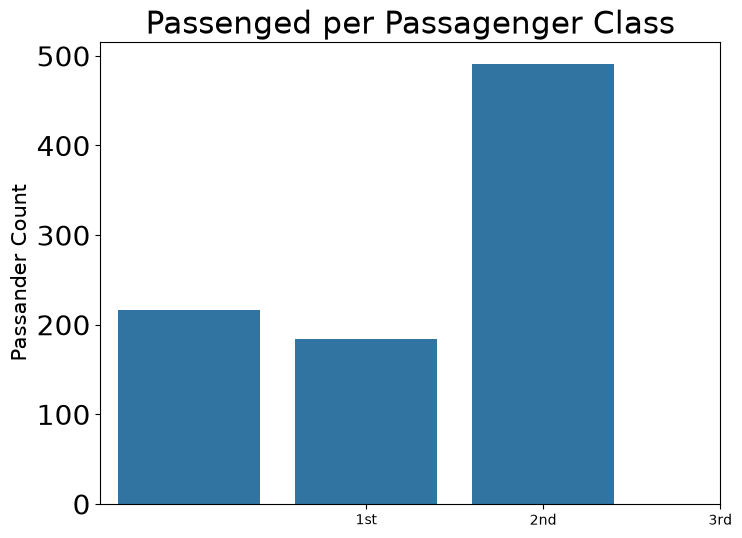

In [25]:
plt.figure(figsize=(8,6))
sns.countplot(x="pclass",data=df,width=.8)
plt.title("Passenged per Passagenger Class", fontsize=22)
plt.xticks(ticks=[1,2,3], labels = ["1st","2nd","3rd"])
plt.yticks(fontsize=20)
plt.xlabel("")
plt.ylabel("Passander Count",fontsize=15)
plt.show()

#title
#x+y ticks
#x+y labels

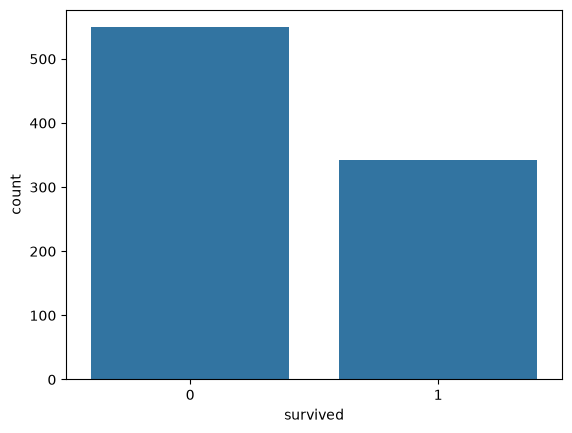

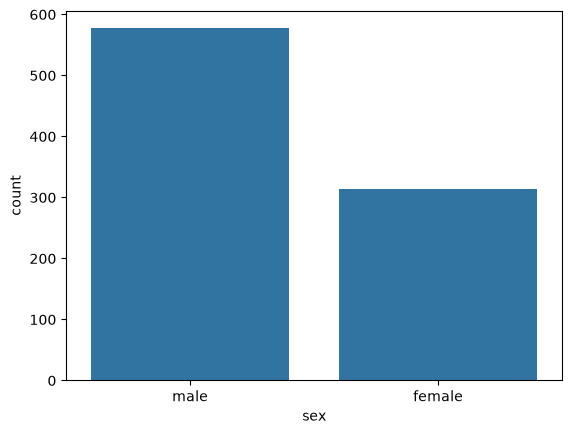

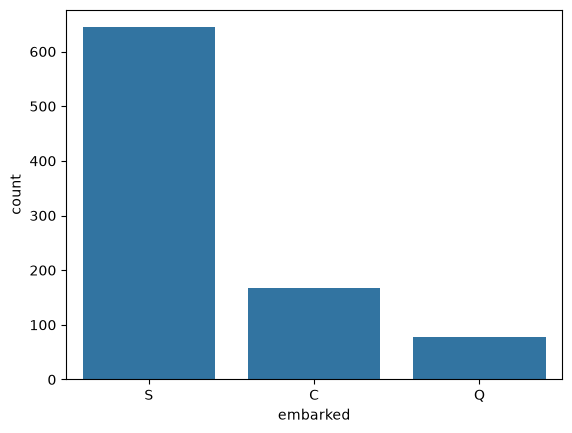

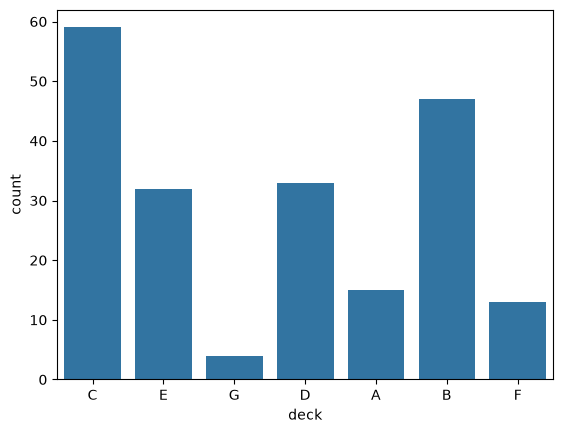

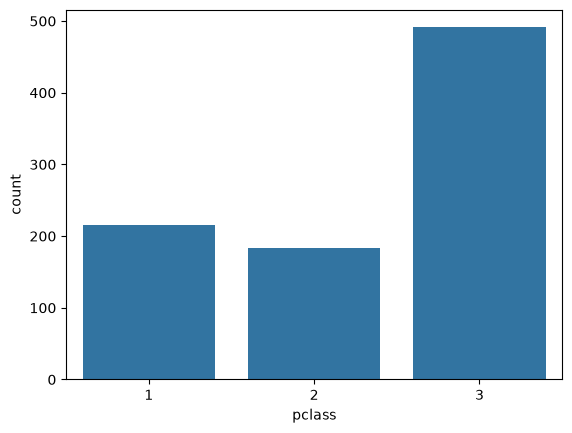

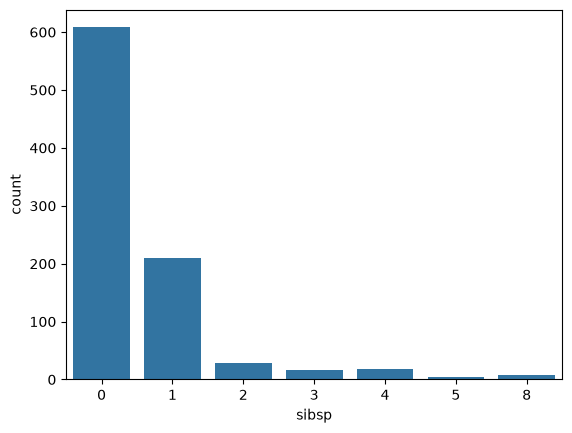

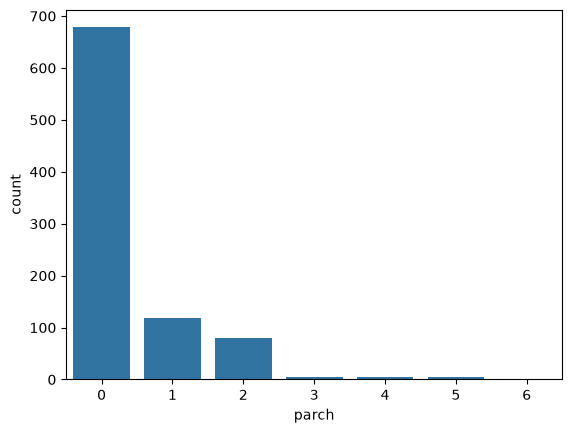

In [24]:
for col in nominal + ordinal + discrete:
    sns.countplot(x=col,data=df)
    plt.show()

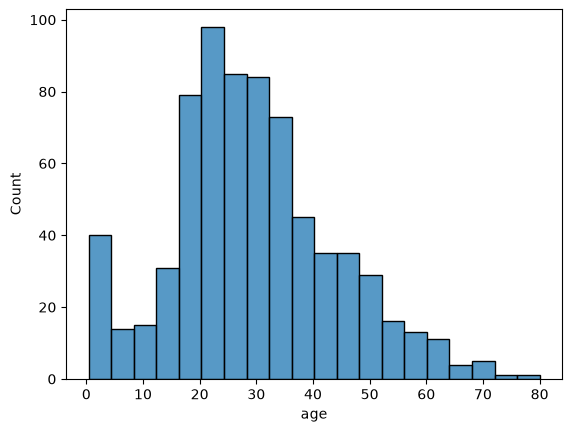

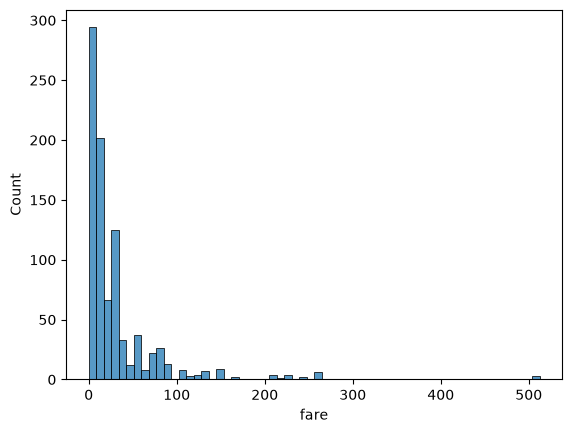

In [31]:
for col in continuos:
    sns.histplot(x=col,data=df, bins="auto")
    plt.show()



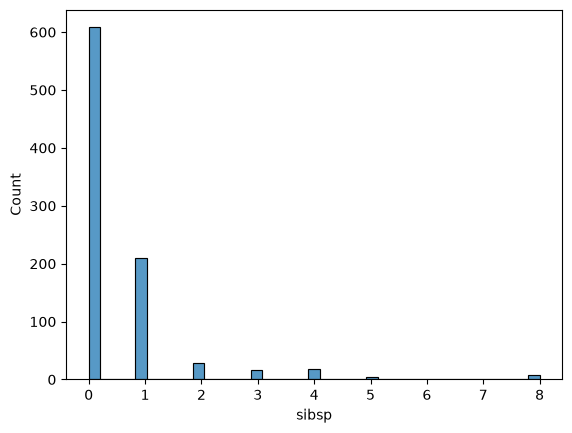

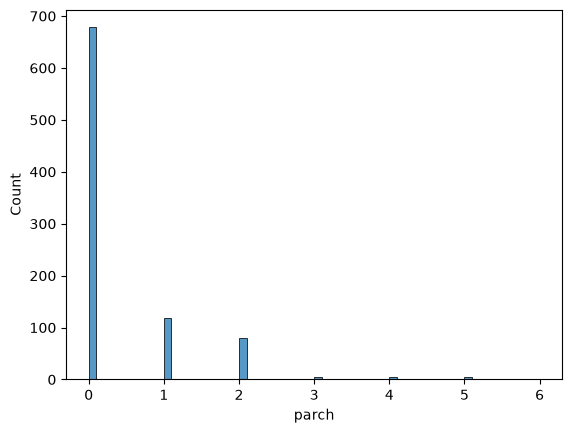

In [28]:
for col in discrete:
    sns.histplot(x=col,data=df)
    plt.show()

<Axes: xlabel='age', ylabel='Density'>

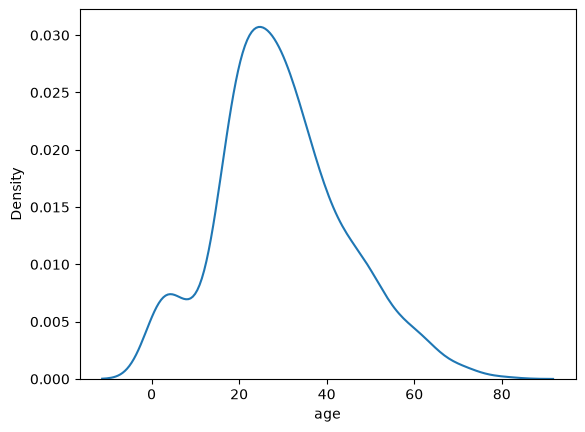

In [ ]:
#kernel density estimation is a soothened version of the histogram that shows the probability distribution of a event
sns.kdeplot(data=df, x="age")

# Box Plots

The Interquartile Range (IQR) is a measure of statistical dispersion, representing the difference between the   25th percentile (Q1) and the 75th percentile (Q3) of a data distribution. It is used to describe the middle 50% of values when ordered. IQR is useful for identifying outliers and understanding the spread of the middle half of a dataset.

Interpreting IQR:

**Spread of the Middle Data**: A larger IQR indicates a wider spread of the middle data.<br>
**Outlier Detection**: Values significantly higher than Q3 + 1.5 * IQR or lower than Q1 - 1.5 * IQR are often considered outliers.<br>
**Comparing Distributions**: IQR can be used to compare the spread of different datasets.<br>

<Axes: xlabel='age'>

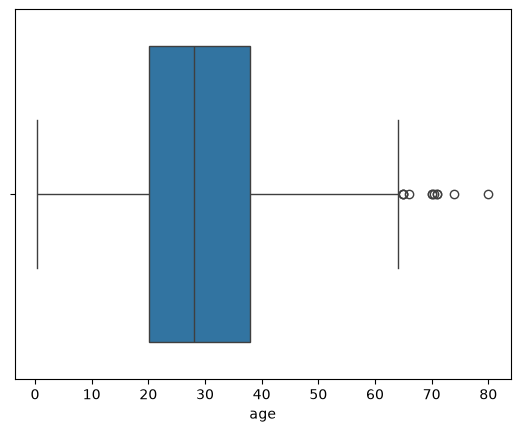

In [33]:
sns.boxplot(data=df, x="age")

In [ ]:
#to find fence (last black bars) we multiply the interquartile range (blue area) by 1.5 and add it to the edge 
#everything after our fence is considered an outlier

## 4. Bivariate/multivariate analysis

<Axes: xlabel='pclass', ylabel='count'>

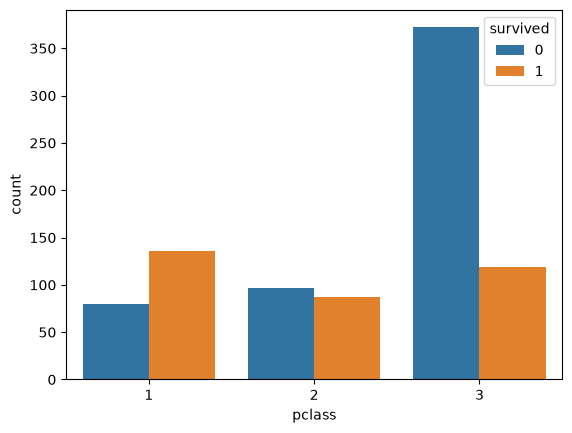

In [35]:
sns.countplot(data=df, x="pclass", hue="survived")

<Axes: xlabel='sex', ylabel='survived'>

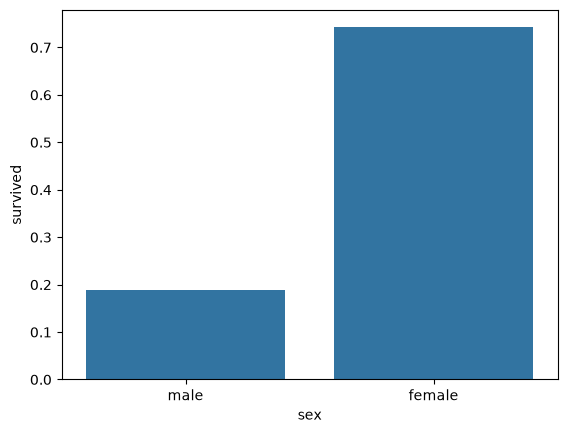

In [ ]:
sns.barplot(data=df, x="pclass", y="survived", estimator="mean",errorbar=None)

<Axes: xlabel='sex', ylabel='survived'>

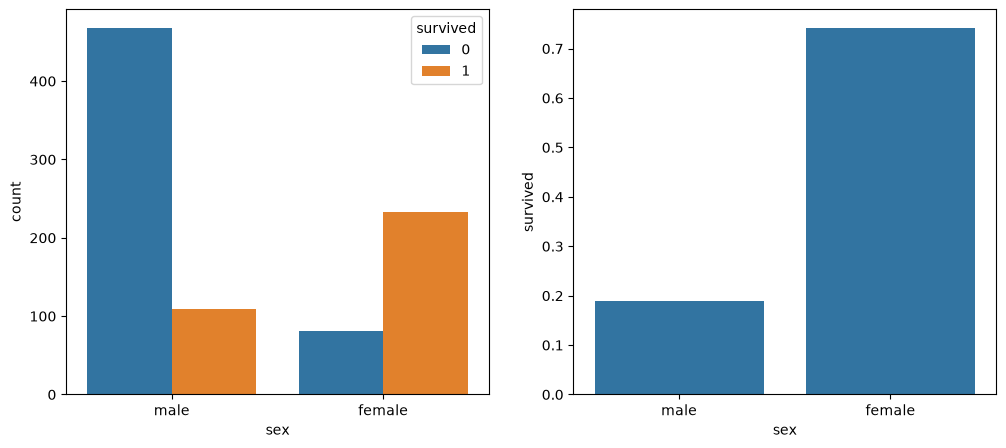

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
#nr rows,nr cols,size of the graph
sns.countplot(data=df, x="sex", hue="survived",ax=ax[0])
sns.barplot(data=df,x="sex", y="survived",estimator="mean",errorbar=None,ax=ax[1])


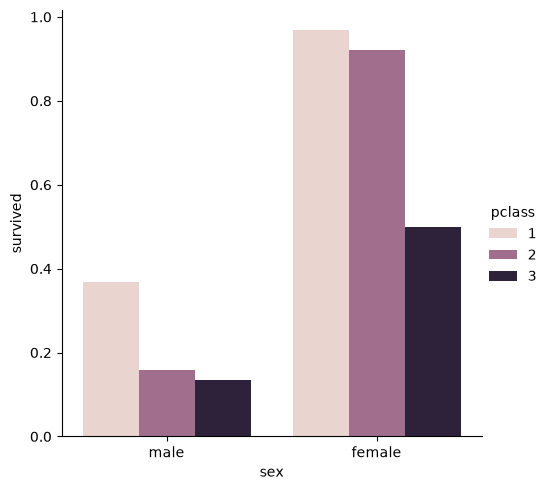

In [ ]:
#cat stands for categoy, not for presentations cause not customizable, its good to see for ourselves
# We can use `kind=` "strip", "swarm", "box", "violin", "boxen", "point", "bar", or "count"


sns.catplot(data=df, x="sex", y="survived", kind="bar",errorbar=None,estimator="mean",hue="pclass")


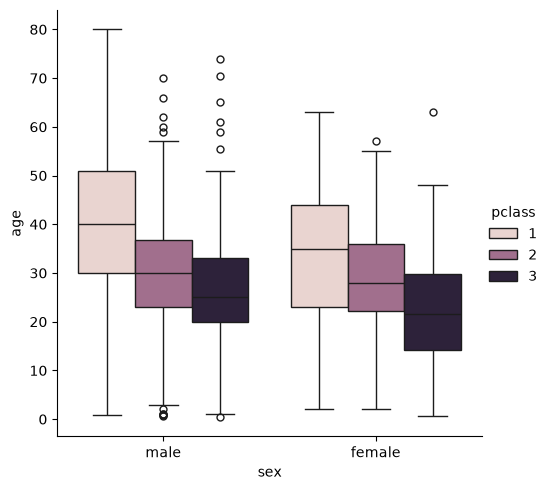

In [48]:
sns.catplot(data=df,x="sex",y="age",kind="box",hue="pclass")

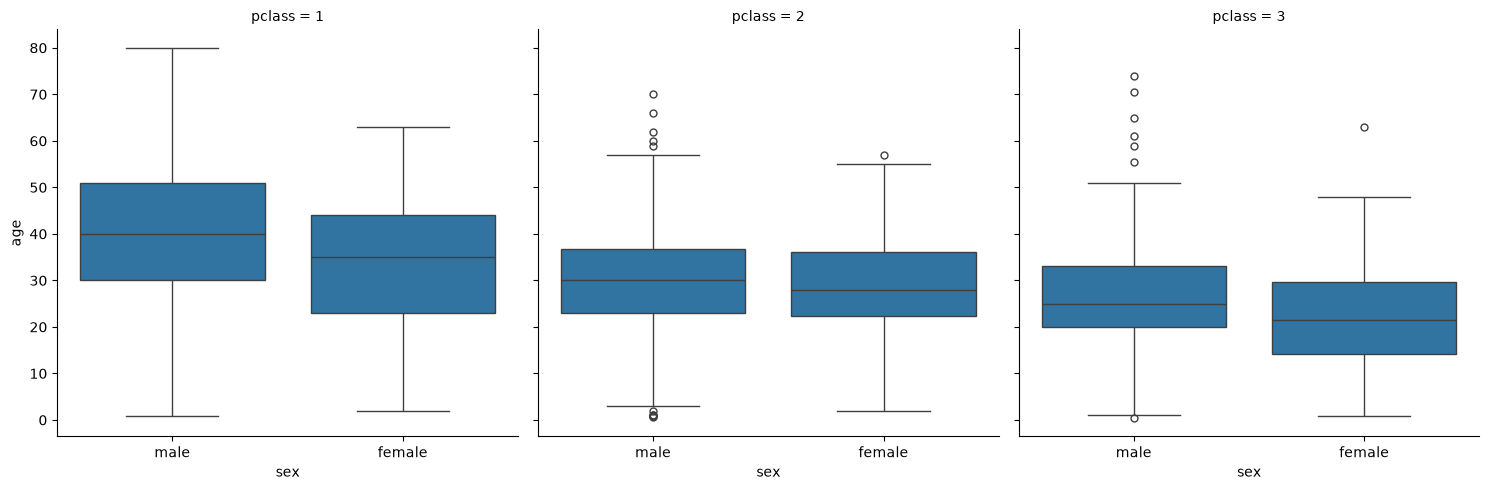

In [49]:
sns.catplot(data=df,x="sex",y="age",kind="box",col="pclass")


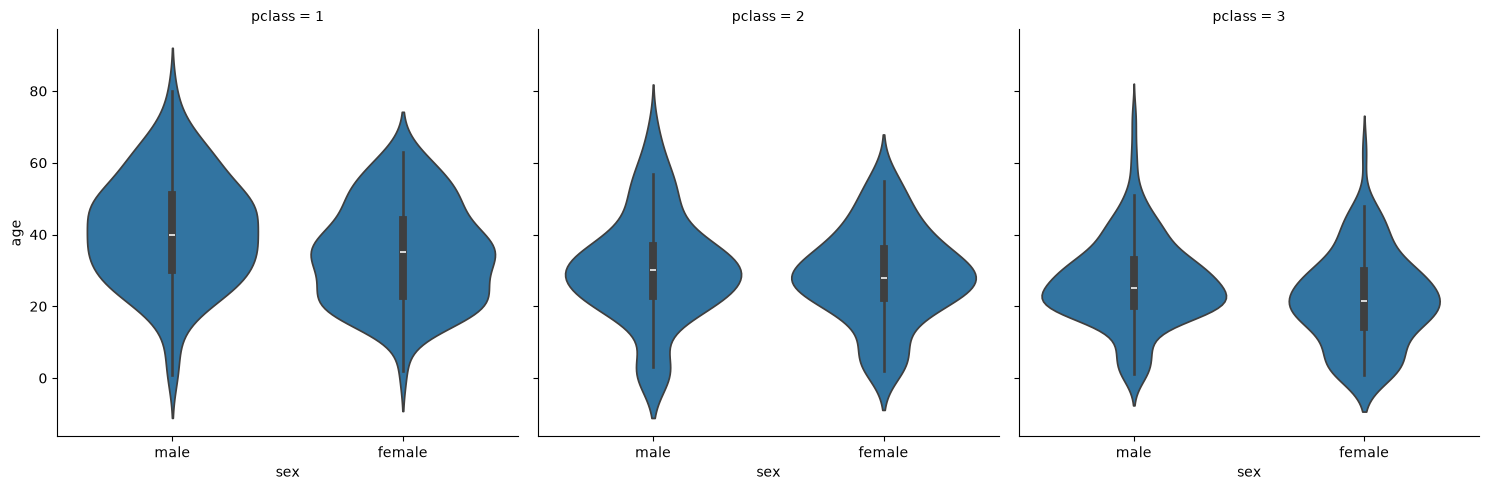

In [ ]:
sns.catplot(data=df,x="sex",y="age",kind="violin",col="pclass")


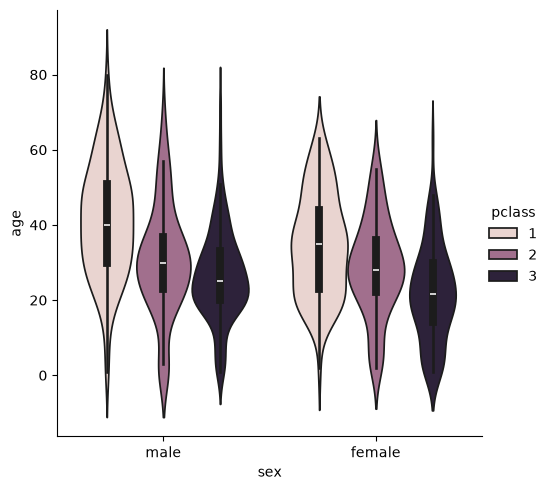

In [54]:
sns.catplot(data=df,x="sex",y="age",kind="violin",hue="pclass")


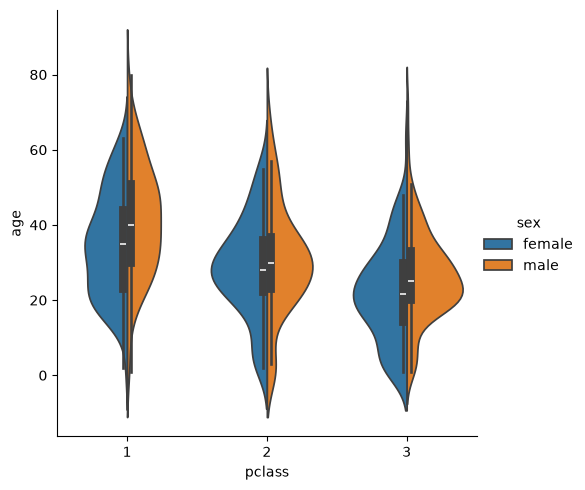

In [55]:
sns.catplot(data=df,x="pclass",y="age",kind="violin",hue="sex",split=True)


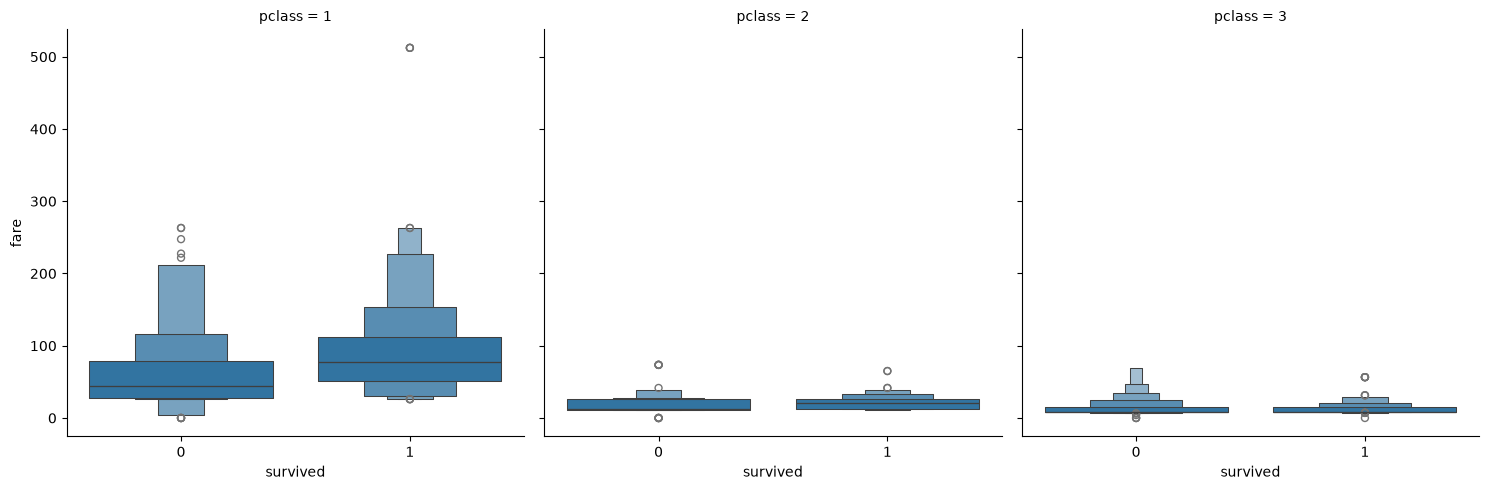

In [56]:
sns.catplot(data=df,x="survived",y="fare",kind="boxen",col="pclass")


<Figure size 12000x8000 with 0 Axes>

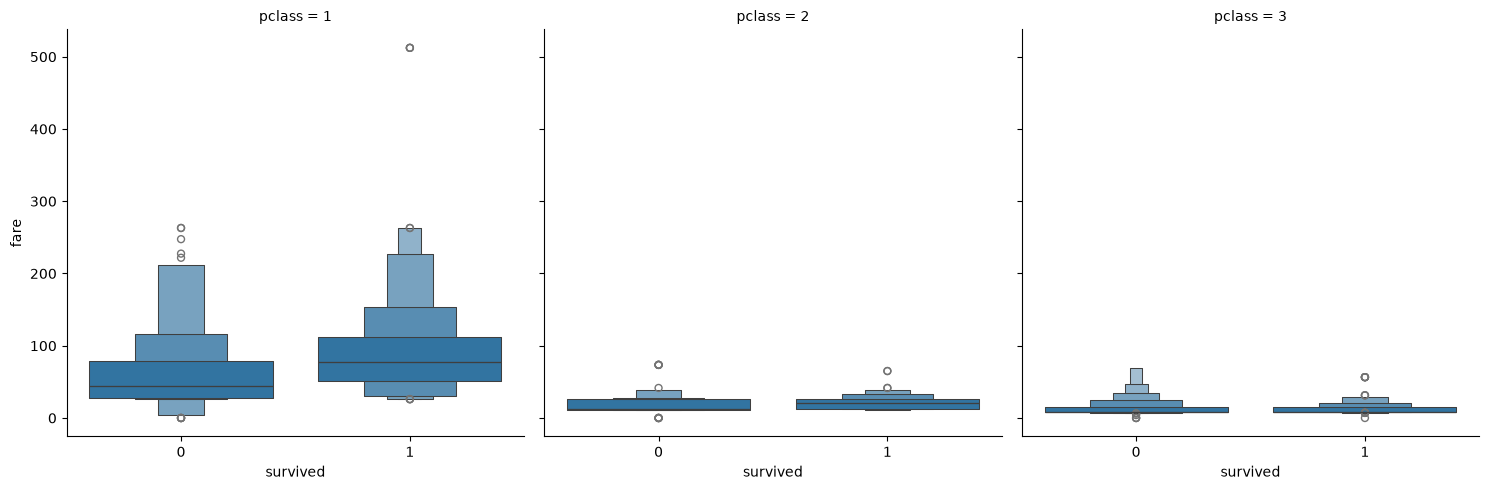

In [59]:
plt.figure(figsize=(120,80))
sns.catplot(data = df, x = 'survived', y = 'fare',  kind = 'boxen', col="pclass",height=5)

<Axes: xlabel='age', ylabel='survived'>

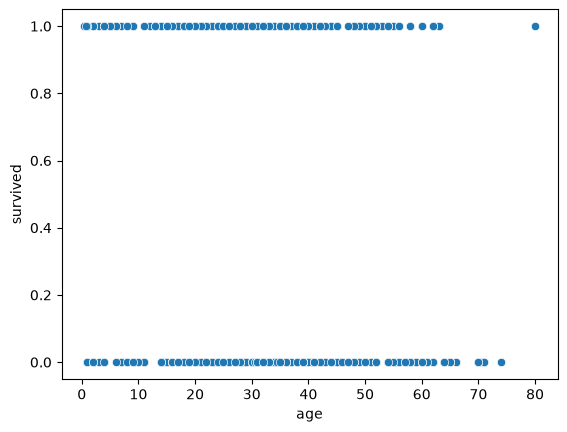

In [61]:
# scatter plot

sns.scatterplot(data=df, x="age",y="survived")

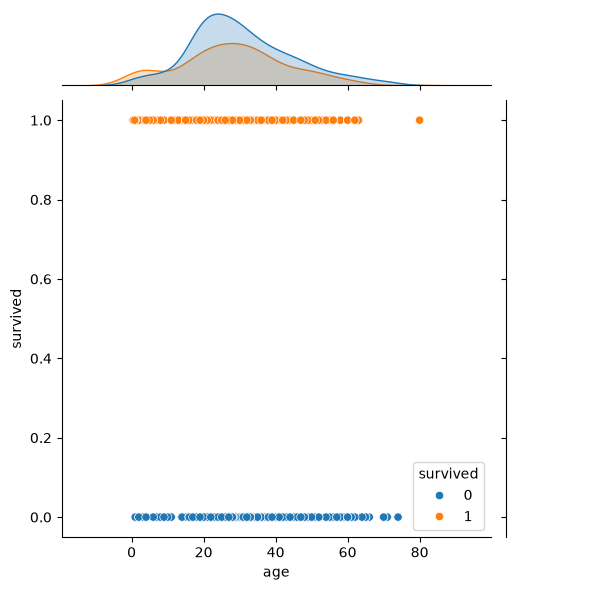

In [63]:
sns.jointplot(data=df, x="age",y="survived",hue="survived")

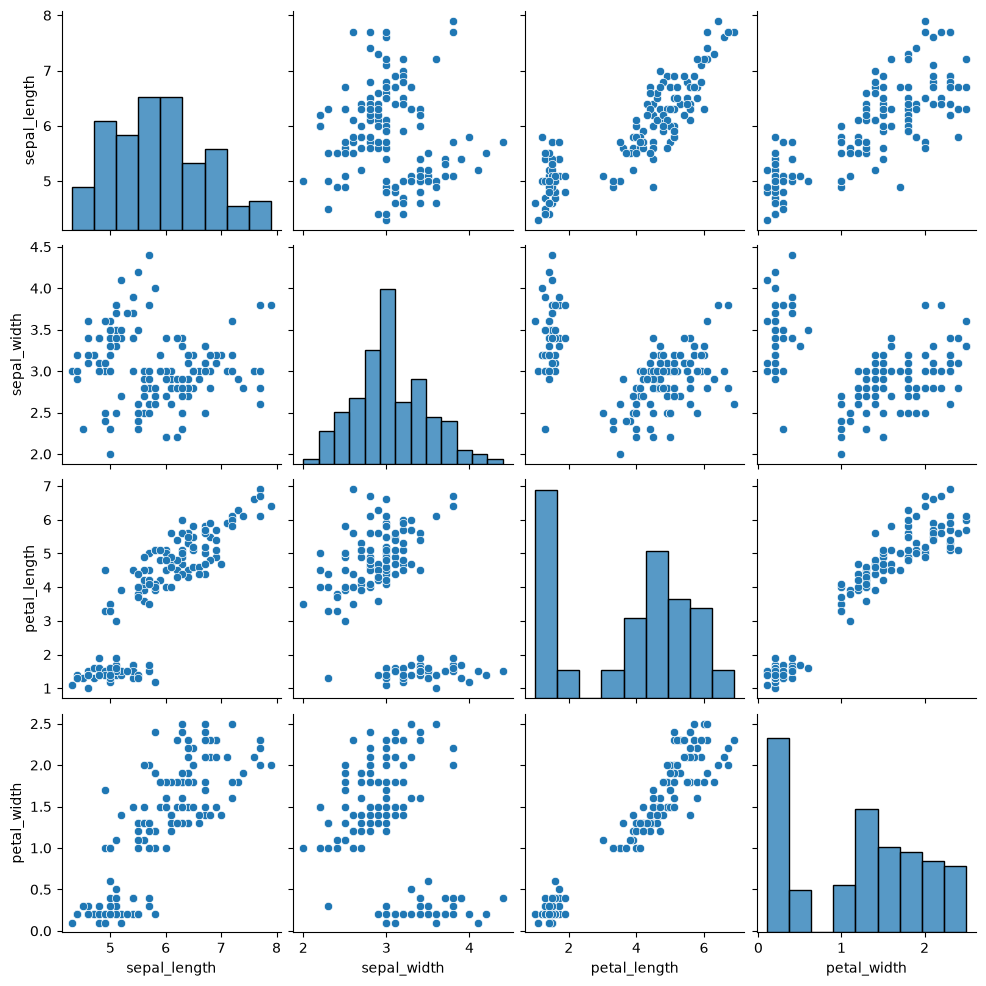

In [65]:
iris = sns.load_dataset("iris")
sns.pairplot(iris)

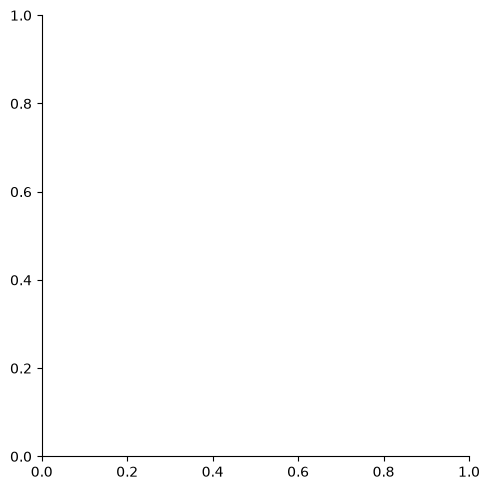

In [ ]:
sns.lmplot(data=iris, )

In [71]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

<Axes: xlabel='sepal_length', ylabel='petal_length'>

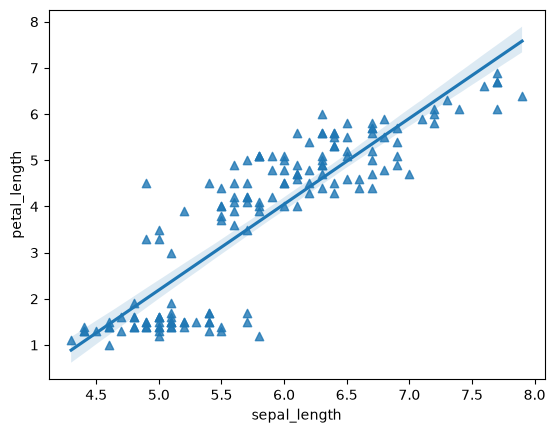

In [72]:
sns.regplot(data=iris, x="sepal_length", y="petal_length", marker="^")